In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 

from sklearn.cluster import AgglomerativeClustering

In [4]:
iris = datasets.load_iris()

In [5]:
iris_data = pd.DataFrame(iris.data)
iris_data.columns = iris.feature_names

iris_data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [13]:
X = iris_data
y = iris.target

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=34)

In [16]:
# Standardization
scaler = StandardScaler()

In [49]:
X_scaled = scaler.fit_transform(X_train)

In [50]:
X_scaled

array([[ 1.20059723,  0.36628637,  1.0245028 ,  1.34119319],
       [-1.02490008, -0.10889595, -1.25422856, -1.34759506],
       [-1.49342583,  0.36628637, -1.36538619, -1.34759506],
       [ 0.61494005,  0.36628637,  0.35755703,  0.3168929 ],
       [-1.25916295,  0.84146868, -1.08749212, -1.34759506],
       [-0.7906372 ,  0.84146868, -1.36538619, -1.34759506],
       [ 0.49780861, -1.77203405,  0.30197822,  0.06081783],
       [-1.25916295, -0.10889595, -1.36538619, -1.21955753],
       [ 0.96633436,  0.60387752,  1.0245028 ,  1.59726826],
       [ 1.0834658 ,  0.36628637,  1.13566042,  1.34119319],
       [-0.08784858,  2.26701563, -1.47654381, -1.34759506],
       [-1.02490008,  1.316651  , -1.36538619, -1.34759506],
       [ 0.49780861, -1.29685173,  0.6354511 ,  0.82904304],
       [ 0.73207148,  0.36628637,  0.69102992,  0.95708058],
       [ 0.1464143 , -0.82166942,  0.69102992,  0.44493044],
       [-0.20498002, -0.58407826,  0.13524178,  0.06081783],
       [-0.55637433,  2.

In [51]:
from sklearn.decomposition import PCA

In [52]:
pca = PCA(n_components=2)

In [53]:
pca

,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [54]:
pca_scaled = pca.fit_transform(Xtrain_scaled)

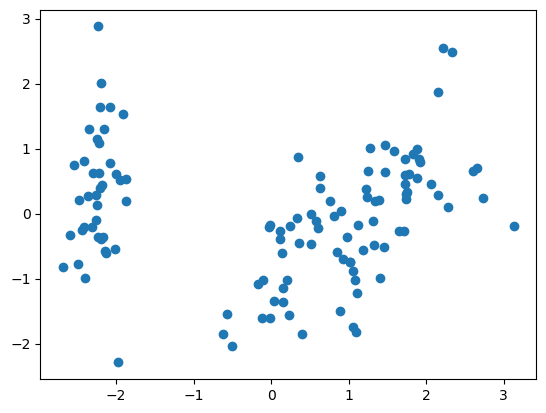

In [55]:
plt.scatter(pca_scaled[:,0], pca_scaled[:,1])

Text(0, 0.5, 'Eucledian Distance')

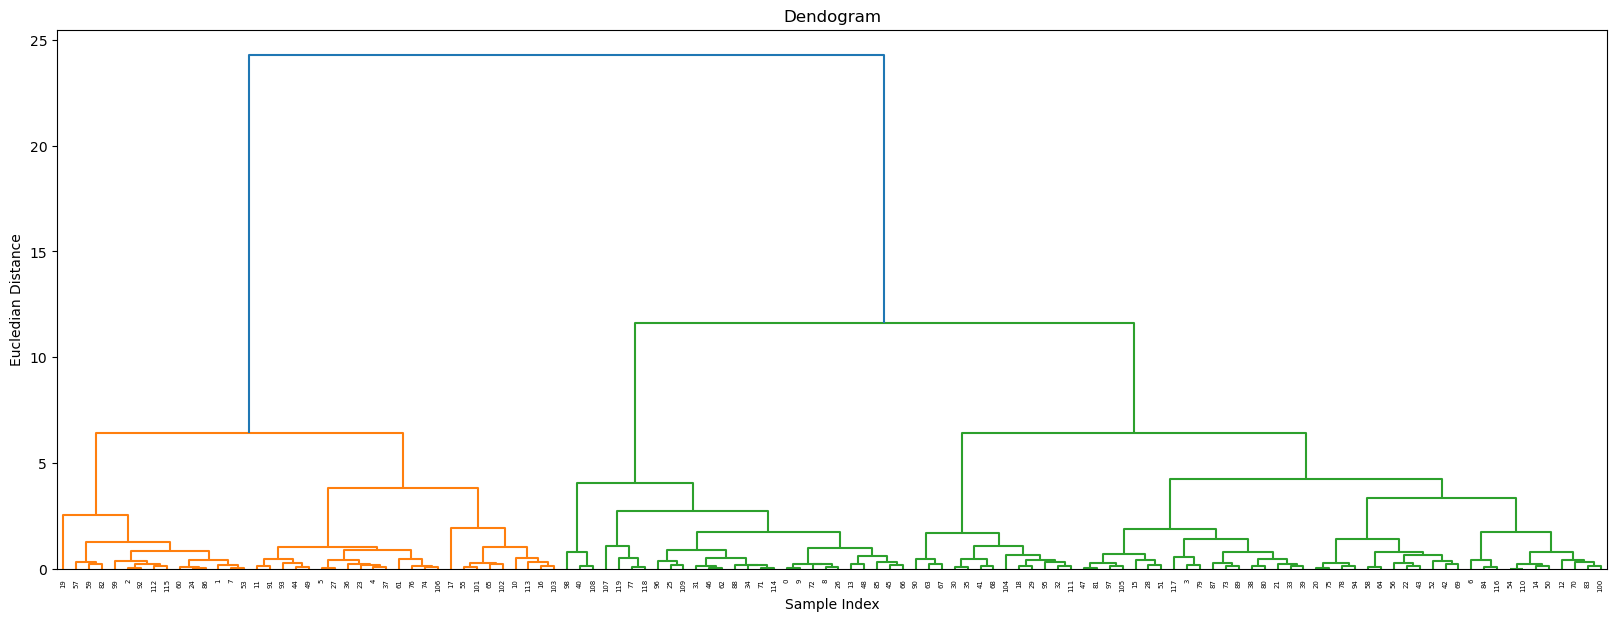

In [56]:
## Aglgomeratice Clustering
## To construct a dendogram
import scipy.cluster.hierarchy as sc
##plot the dendogram
plt.figure(figsize=(20,7))
plt.title("Dendograms")

## create Dendogram
sc.dendrogram(sc.linkage(pca_scaled,method='ward'))
plt.title('Dendogram')
plt.xlabel('Sample Index')
plt.ylabel('Eucledian Distance')

In [57]:
cluster = AgglomerativeClustering(n_clusters=2,metric='euclidean', linkage='ward')
cluster.fit(pca_scaled)

,n_clusters,2
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [58]:
pca_scaled[:1].shape

(1, 2)

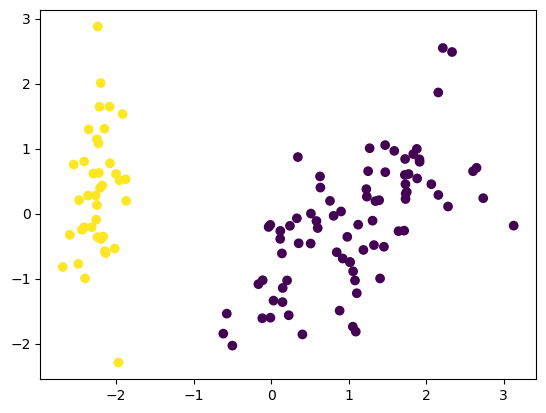

In [61]:
plt.scatter(pca_scaled[:,0], pca_scaled[:,1], c=cluster.labels_)